In [1]:
from typing import Dict

import os
import pickle
from pathlib import Path

import pandas as pd
from tabulate import tabulate

import torch
import pytorch_lightning as pl

from vqniche.utils.parse_test_configs import *
from vqniche.initializers.initialize import *
from vqniche import metrics
from vqniche.utils.type_conversions import *
from vqniche.plotting import *
from vqniche.utils.loss_utils import aggregate_1hop_neighbor_features

/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

In [3]:
def collect_test_configs(
        args: Optional[argparse.Namespace] = None,
        wandb_run_dir: Optional[str] = None,
        model_ckpt_fname: Optional[str] = None,
        ) -> Dict:
    """
    Collect configurations from the config file from the wandb run directory and command line arguments for testing.

    Parameters:
    ----------
    - args (argparse.Namespace): The command line arguments.

    Returns:
    ----------
    - Dict: The configuration dictionary.
    """
    assert args is not None or wandb_run_dir is not None, \
        "Either args or wandb_run_dir must be provided"
    
    # get wandb run directory from command line arguments if provided, otherwise from the wandb_run_dir argument
    if args is not None:
        wandb_run_dir = args.wandb_run_dir
        
    # get config file path from wandb run directory
    config_fname = Path(wandb_run_dir) / 'files' / 'user_specified_config.yaml'
    
    # read parameters from config file
    with open(config_fname, "r") as f:
        config = yaml.safe_load(f)

    # set model checkpoint file name from command line arguments if provided, otherwise from the model_ckpt_fname argument, else find best checkpoint from wandb run directory
    if args is not None:
        if args.model_ckpt_fname is not None:
            config['model']['model_ckpt_fname'] = args.model_ckpt_fname
        else:
            if args.metric_name is not None:
                metric_name = args.metric_name
            else:
                metric_name = config['trainer']['monitor']
            if args.mode is not None:
                mode = args.mode
            else:
                mode = config['trainer']['checkpoint_params']['mode']
            config['model']['model_ckpt_fname'] = find_best_checkpoint(
                                                        wandb_run_dir,
                                                        mode=mode,
                                                        metric_name=metric_name,
                                                    )
    else:
        if model_ckpt_fname is not None:
            config['model']['model_ckpt_fname'] = model_ckpt_fname
        else:
            mode = config['trainer']['checkpoint_params']['mode']
            metric_name = config['trainer']['monitor']
            config['model']['model_ckpt_fname'] = find_best_checkpoint(
                                                        wandb_run_dir,
                                                        mode=mode,
                                                        metric_name=metric_name,
                                                    )

    # write wandb_run_directory and model_ckpt_fname to config
    config['experiment']['wandb_run_dir'] = wandb_run_dir
    config['model']['model_ckpt_fname'] = config['model']['model_ckpt_fname']
    config['experiment']['compute_metrics'] = args.compute_metrics if args is not None else False
    config['experiment']['plot_figures'] = args.plot_figures if args is not None else False

    return config


def find_best_checkpoint(
        wandb_run_dir: str,
        mode: Literal['min', 'max'] = 'max',
        metric_name: Literal['mmd_eigenvalues', 'pearson_1hop_nbr'] = 'pearson_1hop_nbr',
    ) -> str:
    """
    Find checkpoint file name with best metric value.

    Parameters:
    ----------
    - wandb_run_dir: str
        The directory containing the wandb run files.
    - mode: Literal['min', 'max']
        The mode to find the best checkpoint.
    - metric_name: str
        The name of the metric to find the best checkpoint.

    Returns:
    ----------
    - str: The path to the checkpoint file with the best metric value.
    - e.g. if mode is 'max' and metric_name is 'pearson_1hop_nbr', the function will return the checkpoint file with the highest Pearson correlation between the original and reconstructed cell-gene matrices
    - e.g. if mode is 'min' and metric_name is 'mmd_eigenvalues', the function will return the checkpoint file with the lowest MMD between the eigenvalue distributions of the original and reconstructed graphs
    """
    ckpt_dir = Path(wandb_run_dir) / 'files' / 'checkpoints'

    # initialize value of best metric to be the minimum or maximum possible value
    best_metric_val = np.inf if mode == 'min' else -np.inf
    best_ckpt = None
    for f in os.listdir(ckpt_dir):
        if f.endswith('.ckpt'):
            try:
                # Extract metric value from filename like "epoch=X-metric_name=Y.ckpt"
                metric_val = float(f.split(f'{metric_name}=')[1].split('.ckpt')[0])
                if (mode == 'min' and metric_val < best_metric_val) or (mode == 'max' and metric_val > best_metric_val):
                    best_metric_val = metric_val
                    best_ckpt = f
            except:
                continue
    print(f"Best checkpoint found: {best_ckpt}")

    return ckpt_dir / best_ckpt

In [2]:
wandb_run_dir = '/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250918_220115-ldg9jjpv'

config = collect_test_configs(wandb_run_dir = wandb_run_dir)

# --------------------- Determinism Settings ---------------------
pl.seed_everything(config['experiment']['seed'])

# --------------------- Dataset ---------------------
config['dataset']['adata_batch_idx'] = [1]
dataset_blob = initialize_dataset_blob(config)
with open(Path(dataset_blob.processed_dir) / 'label_categories.pkl', 'rb') as f:
    label_categories = pickle.load(f)

# --------------------- Databatch ---------------------
data_batch = initialize_databatch(
                config=config,
                dataset_blob=dataset_blob,
            )

# --------------------- Dataloader ---------------------
datamodule_batch = initialize_datamodule(
                        config=config,
                        data=data_batch,

                    )

# # --------------------- Model ---------------------
# Model = set_model_class(config['model']['model_name'])
# model = Model.load_from_checkpoint(
#             config['model']['model_ckpt_fname'],
#         )
# model.eval()

Seed set to 0


Best checkpoint found: epoch=9-train_pearson_1hop_nbr=0.93.ckpt
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
DataBatch(y_grade=[71118, 2], y_clinical_risk=[71118, 2], xy_coordinates=[71118, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[71118, 1000], y=[71118, 2], edge_index=[2, 729618], encoder_conditions=[71118, 14], encoder_condition_dim=14, spatial_prior_feature_dim=0, attr_decoder_conditions=[71118, 14], attr_decoder_condition_dim=14, adj_decoder_condition_dim=0, num_features=1000, num_classes=2, num_nodes=71118, num_edges=[1], train_mask=[71118], val_mask=[71118], test_mask=[71118], batch=[71118], ptr=[2], adata_batch_ids=[71118])
Batch ID(s): [1]
Data Batch: DataBatch(y_grade=[71118, 2], y_clinical_risk=[71118, 2], xy_coordinates=[71118, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[71118, 

In [3]:
dataset_blob

InMemoryDatasetBlob(5)

In [4]:
for data in dataset_blob:
    print(data)
    

SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
Data(y_grade=[58432, 2], y_clinical_risk=[58432, 2], xy_coordinates=[58432, 2], cell_id=[58432], dataset_id=1020, tissue='kidney', species='homo_sapiens', adata_batch_id=[1], x=[58432, 1000], y=[58432, 2], edge_index=[2, 606914], encoder_conditions=[58432, 8], encoder_condition_dim=8, spatial_prior_feature_dim=0, attr_decoder_conditions=[58432, 8], attr_decoder_condition_dim=8, adj_decoder_condition_dim=0, num_features=1000, num_classes=2, num_nodes=58432, num_edges=606914, train_mask=[58432], val_mask=[58432], test_mask=[58432])
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
Data(y_grade=[71118, 2], y_clinical_risk=[71118, 2], xy_coordinates=[71118, 2], cell_id=[71118], dataset_id=1020, tissue='kidney

In [10]:
config['dataset']['adata_batch_idx']

-1

In [18]:
for batch in datamodule_batch.predict_dataloader():
    print(batch)
    print(batch.x.sum(dim=-1))
    print(batch.attr_decoder_conditions.shape)
    break

Data(x=[801, 1000], edge_index=[2, 4267], y=[801, 2], xy_coordinates=[801, 2], train_mask=[801], val_mask=[801], test_mask=[801], adata_batch_ids=[801], encoder_conditions=[801, 14], attr_decoder_conditions=[801, 14], y_grade=[801, 2], y_clinical_risk=[801, 2], n_id=[801], e_id=[4267], num_sampled_nodes=[3], num_sampled_edges=[2], input_id=[64], batch_size=64)
tensor([ 175.,  383.,  251.,  461.,  121.,  458.,  242.,  364.,  521.,  503.,
         524.,  130.,  342.,  343.,  156.,  526.,  228.,  150.,  458.,  568.,
         251.,  997.,   98.,  381.,  339.,  213.,  206.,  749.,  507.,  399.,
         880.,  441.,  294.,  207.,  499.,   84.,  249.,  405.,   64.,  688.,
         214.,  176.,   50.,  281.,  203.,  252.,   94.,  229.,  322.,  166.,
         237.,  402.,  296.,  340.,  212.,  481.,  362.,  562.,  343.,  325.,
         444.,  239.,  394.,  307.,  155.,  605.,  673.,  414.,  405., 1081.,
         791.,  156., 1371.,  299.,  665.,  420.,  248.,  338.,  211.,  863.,
         167.

In [19]:
batch.x.sum(1)

tensor([ 175.,  383.,  251.,  461.,  121.,  458.,  242.,  364.,  521.,  503.,
         524.,  130.,  342.,  343.,  156.,  526.,  228.,  150.,  458.,  568.,
         251.,  997.,   98.,  381.,  339.,  213.,  206.,  749.,  507.,  399.,
         880.,  441.,  294.,  207.,  499.,   84.,  249.,  405.,   64.,  688.,
         214.,  176.,   50.,  281.,  203.,  252.,   94.,  229.,  322.,  166.,
         237.,  402.,  296.,  340.,  212.,  481.,  362.,  562.,  343.,  325.,
         444.,  239.,  394.,  307.,  155.,  605.,  673.,  414.,  405., 1081.,
         791.,  156., 1371.,  299.,  665.,  420.,  248.,  338.,  211.,  863.,
         167.,  982., 1140.,  135.,  347.,  196.,  171.,  255.,  447., 1104.,
        1054.,  717.,  138.,  470.,  814.,  440.,  116.,  317.,  255.,  846.,
         163.,  466.,  595.,  129.,  478.,  244.,  318.,  310.,  282.,  293.,
         934.,  586.,  648., 1013.,  219.,  808.,  630., 1377., 1228.,  833.,
         887.,  229.,  633.,  290.,  184.,  834.,  384.,  596., 

In [58]:
import pickle as pkl
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
dict_fname = '/nfs/team361/am84/VQNiche/logs/xhs1000-39b_1p/standalone/VQNiche/batch=[11]/spatial_n_neighs_8/wandb/offline-run-20250910_160535-67bzdcqi/results/epoch=0-val_pearson_1hop_nbr=0.80/predict_data_dict.pkl'
dict_fname = '/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250910_145515-w2weep9e/results/epoch=0-train_pearson_1hop_nbr=0.91/predict_data_dict.pkl'
with open(dict_fname, 'rb') as f:
    lc = pkl.load(f)
print(lc.keys())

dict_keys(['X', 'X_nbr', 'XY_coordinates', 'adata_batch_ids', 'H_latent', 'H_quantized', 'H_adj', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'y_grade', 'y_clinical_risk', 'codebook_size', 'separate', 'num_heads', 'edge_index'])


In [32]:
adata_fname = '/nfs/team361/am84/VQNiche/logs/xhs1000-39b_1p/standalone/VQNiche/batch=[11]/spatial_n_neighs_8/wandb/offline-run-20250910_160535-67bzdcqi/results/epoch=0-val_pearson_1hop_nbr=0.80/predict_adata.pkl'
adata_fname = '/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250910_145515-w2weep9e/results/epoch=0-train_pearson_1hop_nbr=0.91/predict_adata.pkl'
adata_fname = '/nfs/team361/am84/VQNiche/logs/xhs1000-39b_1p/standalone/VQNiche/batch=[2, 5, 10, 16]/spatial_n_neighs_8/wandb/offline-run-20250910_163059-6epznsbe/results/epoch=0-train_pearson_1hop_nbr=0.74/predict_adata.pkl'
with open(adata_fname, 'rb') as f:
    adata = pkl.load(f)

In [33]:
adata

AnnData object with n_obs × n_vars = 44145 × 2000
    obs: 'niche_types', 'cell_types', 'adata_batch_ids'
    uns: 'X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads'
    obsm: 'spatial', 'H_latent', 'H_quantized', 'H_adj'

In [25]:
adata.obs['cell_types']

0                KC4-5
1                  KC3
2                  KC1
3           Melanocyte
4                  KC1
             ...      
17827        Mast cell
17828    F2: Universal
17829    F2: Universal
17830    F2: Universal
17831              Mac
Name: cell_types, Length: 17832, dtype: category
Categories (39, object): ['Adipocyte/mSchwann', 'F1: Superficial', 'F2/3: Bridge', 'F2: Universal', ..., 'VE/Pericyte', 'cDC1', 'cDC2', 'pDC']

In [9]:
a0 = sc.read_h5ad('/lustre/scratch126/cellgen/lotfollahi/DATASETS/silver/xhk1020-CV1-CV2-5b_1p/adata_batch0.h5ad')

In [10]:
a0

AnnData object with n_obs × n_vars = 58432 × 4949
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'grade', 'clinical_risk', 'patient', 'n_genes', 'original_cell_id'
    var: 'ensembl_id'
    uns: 'assay', 'batch', 'dataset_id', 'species', 'tissue'
    obsm: 'spatial'

In [16]:
l = ['__abstractmethods__', '__annotations__', '__call__', '__cat_dim__', '__class__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__inc__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setitem__', '__setstate__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_edge_attr_cls', '_edge_to_layout', '_edges_to_layout', '_get_edge_index', '_get_tensor', '_get_tensor_size', '_multi_get_tensor', '_put_edge_index', '_put_tensor', '_remove_edge_index', '_remove_tensor', '_store', '_tensor_attr_cls', '_to_type', 'apply', 'apply_', 'batch', 'clone', 'coalesce', 'concat', 'contains_isolated_nodes', 'contains_self_loops', 'contiguous', 'coo', 'cpu', 'csc', 'csr', 'cuda', 'debug', 'detach', 'detach_', 'edge_attr', 'edge_attrs', 'edge_index', 'edge_stores', 'edge_subgraph', 'edge_weight', 'face', 'from_dict', 'generate_ids', 'get_all_edge_attrs', 'get_all_tensor_attrs', 'get_edge_index', 'get_tensor', 'get_tensor_size', 'has_isolated_nodes', 'has_self_loops', 'is_coalesced', 'is_cuda', 'is_directed', 'is_edge_attr', 'is_node_attr', 'is_sorted', 'is_sorted_by_time', 'is_undirected', 'keys', 'multi_get_tensor', 'node_attrs', 'node_offsets', 'node_stores', 'num_edge_features', 'num_edge_types', 'num_edges', 'num_faces', 'num_features', 'num_node_features', 'num_node_types', 'num_nodes', 'pin_memory', 'pos', 'put_edge_index', 'put_tensor', 'record_stream', 'remove_edge_index', 'remove_tensor', 'requires_grad_', 'share_memory_', 'size', 'snapshot', 'sort', 'sort_by_time', 'stores', 'stores_as', 'subgraph', 'time', 'to', 'to_dict', 'to_heterogeneous', 'to_namedtuple', 'up_to', 'update', 'update_tensor', 'validate', 'view', 'x', 'y']
for i in l:
    if i.startswith('y'):
        print(i)

y


In [39]:
adata = sc.read_h5ad('/lustre/scratch126/cellgen/lotfollahi/DATASETS/silver/mmb0-239b_1p/harmonised_merfish_mouse_brain_239-batch_batch1.h5ad')
adata

AnnData object with n_obs × n_vars = 9499 × 1085
    obs: 'donor_id', 'brain_section_label', 'major_brain_region', 'ccf_region_name', 'cell_type', 'cell_id', 'n_genes'
    var: 'ensembl_id'
    uns: 'age', 'age_group', 'assay', 'batch', 'citation', 'dataset_id', 'disease_level1', 'disease_level2', 'disease_level3', 'log1p', 'sample', 'schema_reference', 'schema_version', 'sex', 'species', 'study', 'tissue', 'title'
    obsm: 'X_CCF', 'X_umap', 'spatial'

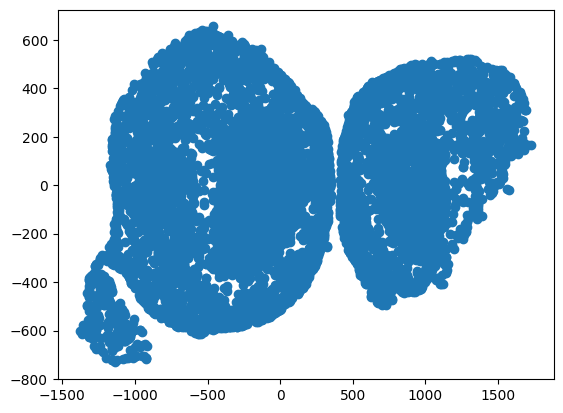

In [40]:
fig, ax = plt.subplots(1,1)
ax.scatter(adata.obsm['spatial'][:,0],adata.obsm['spatial'][:,1])

In [42]:
adata = sc.read_h5ad('/nfs/team361/am84/VQNiche/DATASETS/bronze/xhs1021-1b_1p/adata_3d.h5ad')
adata

AnnData object with n_obs × n_vars = 332916 × 5001
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'xenium_id', 'xenium_id_recoded', 'Site_status', 'GSTT patient ID', 'Sanger patient ID', 'Drug', 'Responder', 'Timepoint', "Library type (CITE or 5'GEX/TCR)", 'Segmentation Y/N?', 'Sample ID', 'Xenium slide number', 'Xenium region number2', 'baseline_postrx', 'info_id', 'Annotation', 'NICHE_NAMES', 'batch', 'DonorID', 'Site_status_binary', 'lvl5_annotation', 'lvl4_annotation', 'lvl3_annotation', 'Mapping_status', 'disease_overall', 'info_

In [61]:
section_ids = adata.obs['sample_id'].unique().tolist()
sorted_sample_ids = [
 'output-XETG00055__0056853__BK22-SKI-27-FO-1-S17-A1__20250710__124204',
 'output-XETG00055__0056865__BK25-SKI-27-FO-5-S13-B1__20250710__124204',
 'output-XETG00055__0056865__BK25-SKI-27-FO-5-S19-C1__20250710__124204',
 'output-XETG00055__0056853__BK22-SKI-27-FO-1-S34-D1__20250710__124204',
 'output-XETG00055__0056853__BK22-SKI-27-FO-1-S41-A2__20250710__124204',
 'output-XETG00055__0056865__BK25-SKI-27-FO-5-S34-A2__20250710__124204',
 'output-XETG00055__0056853__BK22-SKI-27-FO-1-S23-B1__20250710__124204',
 'output-XETG00055__0056853__BK22-SKI-27-FO-1-S46-B2__20250710__124204',
 'output-XETG00055__0056865__BK25-SKI-27-FO-5-S41-B2__20250710__124204',
 'output-XETG00055__0056853__BK22-SKI-27-FO-1-S51-C2__20250710__124204',
 'output-XETG00055__0056865__BK25-SKI-27-FO-5-S46-C2__20250710__124204',
 'output-XETG00055__0056853__BK22-SKI-27-FO-1-S57-D2__20250710__124204',
 'output-XETG00055__0056865__BK25-SKI-27-FO-5-S51-D2__20250710__124204',
 'output-XETG00055__0056865__BK25-SKI-27-FO-5-S24-D1-S29-E1__20250710__124204',  # special case
]

(24121, 5001)
(17926, 5001)
(17312, 5001)
(25133, 5001)
(20774, 5001)
(21072, 5001)
(21593, 5001)
(26324, 5001)
(18859, 5001)
(23792, 5001)
(20914, 5001)
(22364, 5001)
(20523, 5001)
(36094, 5001)


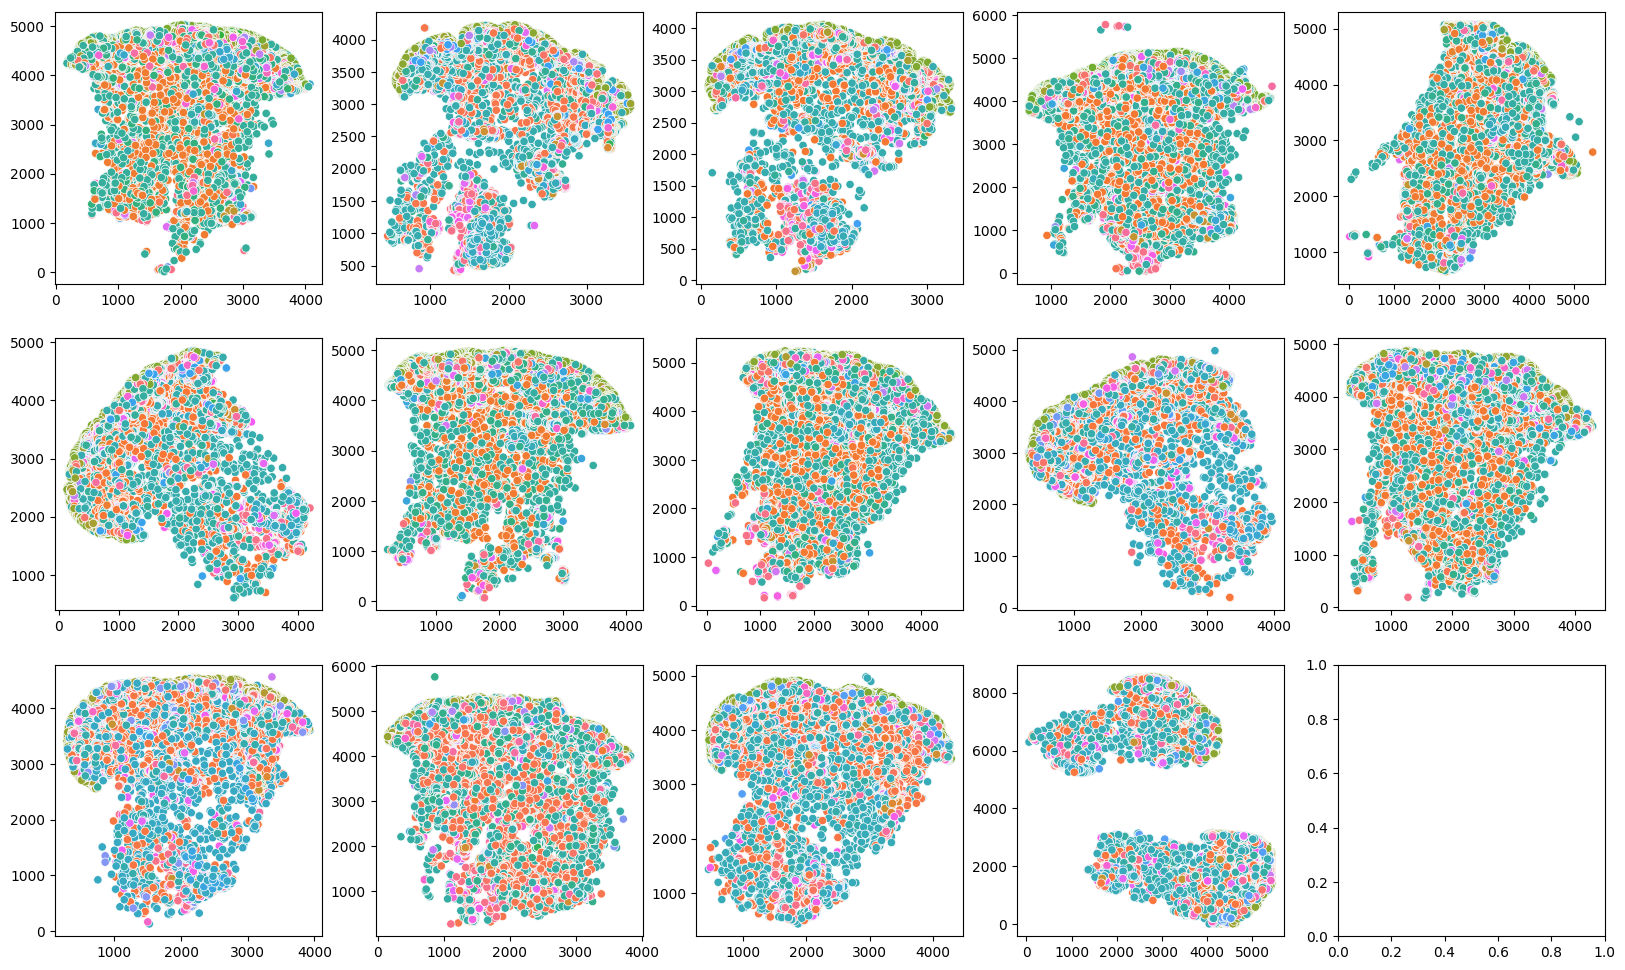

In [64]:
adata_list = []
fig, ax = plt.subplots(3, 5, figsize=(20,12))
ax = ax.flatten()
for i, sample_id in enumerate(sorted_sample_ids):
    a = adata[adata.obs['sample_id'] == sample_id]
    print(a.shape)
    sns.scatterplot(
        x=a.obsm['spatial'][:,0],
        y=a.obsm['spatial'][:,1],
        hue=a.obs['scanvi_predictions'],
        ax=ax[i],
        legend=False
    )

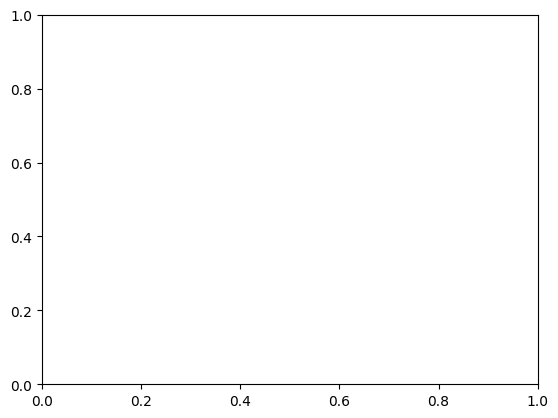

In [60]:
fig, ax = plt.subplots(1,1)
# ax.scatter(adata.obsm['spatial'][:,0],adata.obsm['spatial'][:,1])
# adata.obsm['spatial']